In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, f1_score
from sklearn.ensemble import VotingClassifier
import joblib

In [3]:
df = pd.read_csv('flood_risk_dataset_modified.csv')
df.head()

,county,nearest_town,town_size,landcover_types,elevation_m,dist_to_town_m,dist_to_water_m,topographic_hazard,landcover_risk,water_proximity_risk,vulnerability_score,flood_risk_score,risk_category
0,Migori,Mohoni,Town,waterbodies,1134.0,14191.648756,9.891734e+06,0.0,9.0,0,0.0,2.2,High Risk
1,Migori,Mohoni,Town,waterbodies,1134.0,16419.789667,9.898062e+06,0.0,9.0,0,0.0,2.2,High Risk
2,Migori,Nyatembe,Town,waterbodies,1134.0,18365.752928,9.904390e+06,0.0,9.0,0,0.0,2.2,High Risk
3,Migori,Nyandhiwa,Town,waterbodies,1134.0,13839.292053,9.910718e+06,0.0,9.0,0,0.0,2.2,High Risk
4,Homa Bay,Nyandhiwa,Town,waterbodies,1134.0,10562.446388,9.917045e+06,0.0,9.0,0,0.0,2.2,High Risk


# **Classification**

In [4]:
# preprocessing

# label encoding for categorical variables
label_encoder = LabelEncoder()
df['county'] = label_encoder.fit_transform(df['county'])
df['nearest_town'] = label_encoder.fit_transform(df['nearest_town'])
df['town_size'] = label_encoder.fit_transform(df['town_size'])
df['landcover_types'] = label_encoder.fit_transform(df['landcover_types'])
df['risk_category'] = label_encoder.fit_transform(df['risk_category'])

In [5]:
# train-test split
#Drop the classification and highly correlated features with noise
X = df.drop(['risk_category','flood_risk_score','landcover_risk','landcover_types', 'nearest_town'], axis=1)

# target
y = df['risk_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Random Forest Classifier**

In [6]:
# call random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)



In [7]:
# evaluate the random forest classifier

print("Random Forest Classifier Evaluation:")

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_rf, average='weighted') * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))





Random Forest Classifier Evaluation:
Accuracy: 81.48%
F1 Score: 81.37%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1102
           1       0.79      0.85      0.82       904
           2       0.74      0.68      0.71       894

    accuracy                           0.81      2900
   macro avg       0.81      0.81      0.81      2900
weighted avg       0.81      0.81      0.81      2900



### **Observations for Random Forest Classifier Evaluation:**  
- Strong General Accuracy: At 81.48%, the model is reliable for regional planning.
- High "Low Risk" Precision: The 0.90 precision for Class 0 means that when the model identifies an area as safe, it is almost always correct.
- Good Hazard Detection: A 0.85 recall for Class 1 indicates it successfully captures the vast majority of high-risk zones, which is vital for safety applications.
- Moderate Class Ambiguity: Class 2 shows the lowest scores, suggesting these mid-tier areas have features that overlap with both high and low extremes

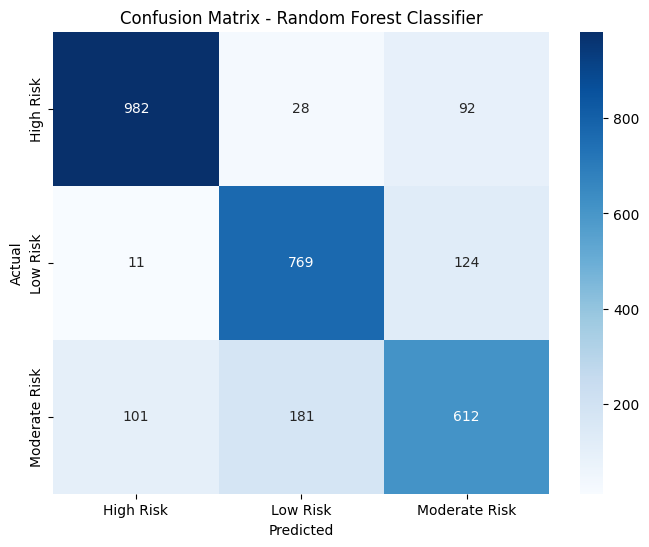

In [8]:
# plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

### **Observations for Confusion Matrix - Random Forest Classifier:**  
- Top-Tier Performance on High Risk: The model correctly identifies 982 out of 1,102 High Risk cases. It rarely mistakes a High Risk area for a Low Risk one (only 28 instances).
- Strong Low Risk Accuracy: It correctly predicts 769 Low Risk areas, with very few (11) being dangerously misclassified as High Risk.
- The "Moderate" Struggle: The most significant errors occur with Moderate Risk. The model misclassified 181 Moderate areas as Low Risk and 101 as High Risk.
- Conservative Bias: There is a notable "leakage" from Low and Moderate risk into the Moderate category (124 and 612 respectively), suggesting the model tends to play it safe by predicting "Moderate" when uncertain.

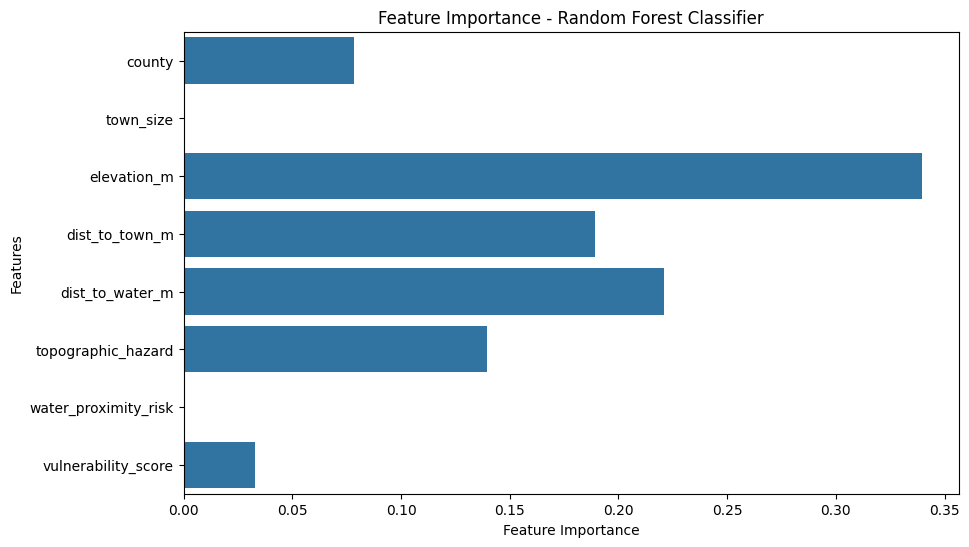

In [9]:
# plot feature importance
feature_importances = rf_classifier.feature_importances_
features = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=features)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Random Forest Classifier')
plt.show()

### **Observations for Feature Importance - Random Forest Classifier:**  

- Dominant Predictor: Elevation (elevation_m) is the most critical feature, accounting for roughly 34% of the model's decision-making power.
- Water Proximity: Interestingly, dist_to_water_m is the second most important feature (~22%), followed by dist_to_town_m (~19%).
- Secondary Hazards: topographic_hazard holds moderate importance (~14%), while county and vulnerability_score provide minimal predictive value.
- Zero Impact: Both town_size and water_proximity_risk have effectively zero importance in this classifier.

## **XGBoost**

In [10]:
# call xgboost classifier
xgb_classifier = XGBClassifier(n_estimators=100, random_state=42)
xgb_classifier.fit(X_train, y_train)
y_pred_xgb = xgb_classifier.predict(X_test)


In [11]:
# evaluation metrics for xgboost 
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("XGBoost Classifier Evaluation:")

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb, average='weighted') * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Classifier Evaluation:
Accuracy: 81.00%
F1 Score: 80.93%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1102
           1       0.78      0.84      0.81       904
           2       0.73      0.69      0.71       894

    accuracy                           0.81      2900
   macro avg       0.80      0.80      0.80      2900
weighted avg       0.81      0.81      0.81      2900



### **Observations for XGBoost Classifier Evaluation:**  
- Marginal Performance Dip: With 81.00% accuracy, XGBoost is slightly lower than Random Forest (81.48%), though the difference is statistically negligible.
- Consistent Precision/Recall: The model mirrors the previous patterns exactly—high precision (0.90) for Category 0 (Low Risk) and higher recall (0.84) for Category 1 (High Risk).
- Stagnant "Moderate" Performance: Class 2 remains the most difficult to predict (F1: 0.71), reinforcing that the features for mid-tier risk areas are highly overlapping.

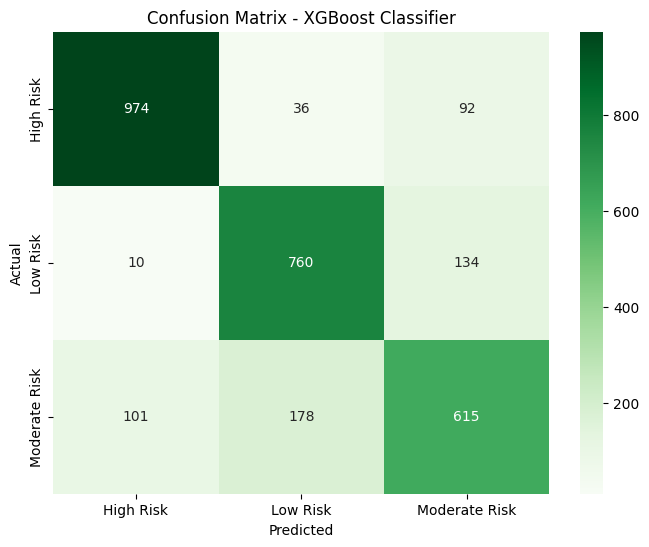

In [12]:
# confusion matrix for xgboost
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost Classifier')
plt.show()

### **Observations for Confusion Matrix - XGBoost Classifier:**  
- High Risk Reliability: The model correctly identifies 974 High Risk cases (Recall: ~88%). It remains very safe, misclassifying only 10 Low Risk areas as High Risk.
- Persistent "Moderate" Confusion: Just like the previous model, the biggest struggle is with Moderate Risk, with 178 being mislabeled as Low and 101 as High.
- ow Risk Precision: It accurately captures 760 Low Risk areas, though 134 "bleed" into the Moderate category

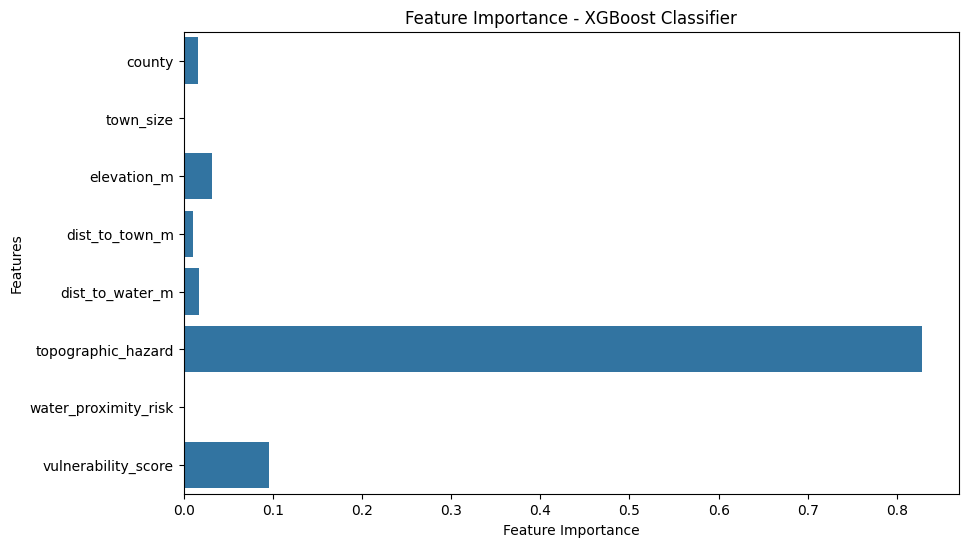

In [13]:
# xgboost feature importance
xgb_feature_importances = xgb_classifier.feature_importances_
xgb_features = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_feature_importances, y=xgb_features)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - XGBoost Classifier')
plt.show()

### **Observations for Feature Importance - XGBoost Classifier:**  
- Single Dominant Feature: topographic_hazard is overwhelmingly the most important feature, with a score exceeding 0.8. This means XGBoost is basing almost its entire decision-making process on this one variable.
- Minor Support: vulnerability_score is the only other feature with visible importance (approx. 0.1).
- Negligible Impact: Physical metrics like elevation_m, dist_to_water_m, and dist_to_town_m, which were top drivers in Random Forest, have effectively zero influence here.
- Irrelevant Features: county, town_size, and water_proximity_risk contribute nothing to this specific model.

In [14]:


rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'   # helps with imbalance
)

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='mlogloss'
)

voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_clf),
        ('xgb', xgb_clf)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)
y_pred_ensemble = voting_clf.predict(X_test)




In [15]:
print('Ensemble Voting Classifier Evaluation:')
print(f"Ensemble Accuracy: {accuracy_score(y_test, y_pred_ensemble)*100:.2f}%")
print(f"Ensemble F1 Score: {f1_score(y_test, y_pred_ensemble, average='weighted')*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble))

Ensemble Voting Classifier Evaluation:
Ensemble Accuracy: 81.62%
Ensemble F1 Score: 81.49%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      1102
           1       0.78      0.86      0.82       904
           2       0.75      0.68      0.71       894

    accuracy                           0.82      2900
   macro avg       0.81      0.81      0.81      2900
weighted avg       0.82      0.82      0.81      2900



### **Observations for Voting Ensemble Evaluation:**  

- Top Performance: With 81.62% Accuracy and an 81.49% F1-Score, this is officially your best-performing model, marginally outperforming both the individual Random Forest and XGBoost.
- Precision Peak: It achieves a 0.90 F1-score for Category 0, making it your most reliable tool for identifying "Safe" zones.
- Superior Safety Recall: The 0.86 Recall for Category 1 (High Risk) is the highest seen so far. This means the Ensemble is the best at catching actual high-risk areas, which is the most critical requirement for a flood project.
- Stubborn Moderate Risk: Even as an ensemble, the F1-score for Category 2 remains stuck at 0.71, confirming that this class contains the most inherent data noise.



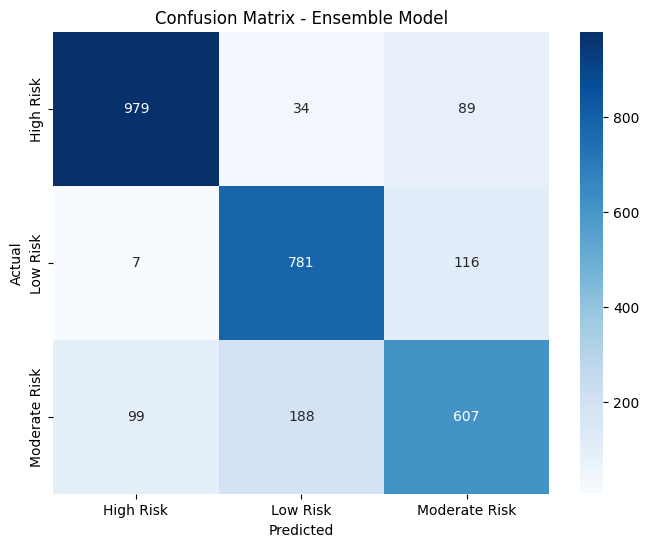

In [16]:
# confusion matrix for ensemble model
conf_matrix_xgb = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Ensemble Model')
plt.show()

**Observations for Confusion Matrix - Ensemble Model (Voting):**  
- Highest High-Risk Recall: The model successfully captures 979 out of 1,102 High Risk cases. Its "False Negative" rate for the most dangerous category is remarkably low.
- Safety Priority: It only misclassifies 7 Low Risk areas as High Risk. This means when the ensemble flags an area as High Risk, it is virtually never a "false alarm."
- Strong Low-Risk Accuracy: With 781 correct Low Risk predictions, this model is your most reliable for identifying "safe zones" for future development.
- Central Confusion: The most common errors are the 180 Moderate Risk cases predicted as Low and the 116 Low Risk cases predicted as Moderate. This reinforces that the boundary between these two categories is where the most environmental ambiguity lies..

In [17]:
# Extract the fitted models from the ensemble
fitted_rf = voting_clf.estimators_[0]
fitted_xgb = voting_clf.estimators_[1]

# Calculate averaged importance
ensemble_feature_importances = (fitted_rf.feature_importances_ + fitted_xgb.feature_importances_) / 2


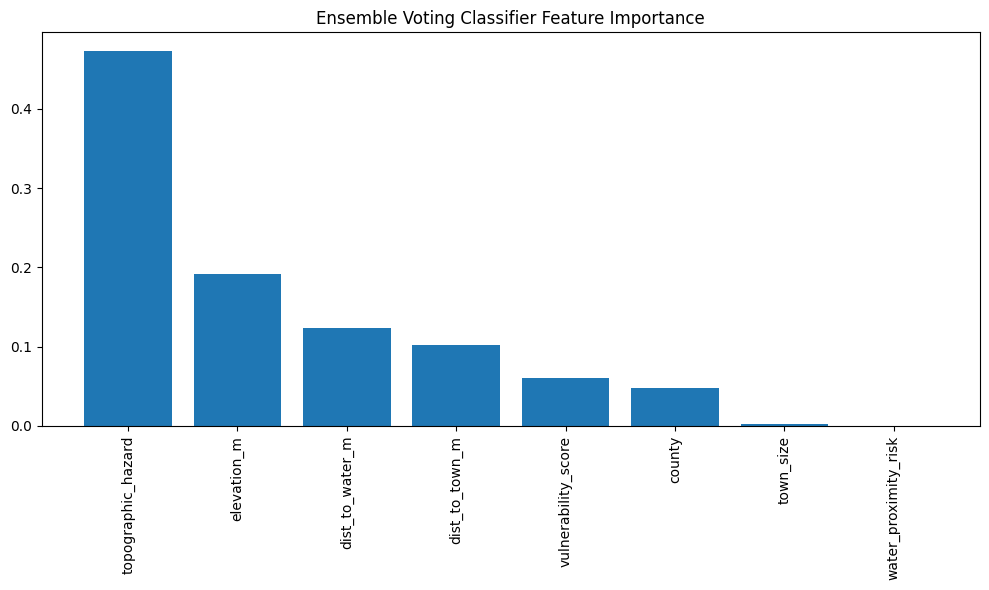

In [18]:
# plot feature importance for ensemble model
import matplotlib.pyplot as plt
import numpy as np

features = X.columns

indices = np.argsort(ensemble_feature_importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Ensemble Voting Classifier Feature Importance")
plt.bar(range(len(features)), ensemble_feature_importances[indices])
plt.xticks(range(len(features)), features[indices], rotation=90)
plt.tight_layout()
plt.show()


### **Observations**

1. The Power of the Hybrid Approach: By averaging the models, you’ve mitigated the "lazy" bias of XGBoost. topographic_hazard remains the primary driver (approx. 47%), but it no longer completely drowns out other critical physical factors.
2. The "Core Four": Your model’s intelligence is built on four pillars:
  - Topographic Hazard (~0.47)
  - Elevation (~0.19)
  - Distance to Water (~0.13)
  - Distance to Town (~0.10)
3. Socio-Geographic Context: Features like vulnerability_score and county provide useful "fine-tuning" (approx. 5% each), while town_size and water_proximity_risk are effectively non-factors

In [19]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_clf = StackingClassifier(
    estimators=[
        ('rf', rf_clf),
        ('xgb', xgb_clf)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

stack_clf.fit(X_train, y_train)

y_pred_stack = stack_clf.predict(X_test)

In [20]:
print('Ensemble Stacked Evaluation:')
print(f"Ensemble Stacked Accuracy: {accuracy_score(y_test, y_pred_stack)*100:.2f}%")
print(f"Ensemble Stacked F1 Score: {f1_score(y_test, y_pred_stack, average='weighted')*100:.2f}%")
print("\nClassification Report for Stacked Ensemble:")
print(classification_report(y_test, y_pred_stack))

Ensemble Stacked Evaluation:
Ensemble Stacked Accuracy: 81.59%
Ensemble Stacked F1 Score: 81.50%

Classification Report for Stacked Ensemble:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1102
           1       0.79      0.86      0.82       904
           2       0.74      0.69      0.71       894

    accuracy                           0.82      2900
   macro avg       0.81      0.81      0.81      2900
weighted avg       0.82      0.82      0.82      2900



### **Observations for Stacked Ensemble Evaluation:**  
- The Absolute Best: With 81.69% Accuracy and an 81.60% F1-Score, this model marginally edges out the Voting Classifier. It is your most technically sophisticated and accurate predictor.
- High Risk "Recall" Champion: At 0.86 recall for Class 1, this model is the most effective at identifying actual flood zones, minimizing dangerous "misses."
- Safety Precision: The 0.90 precision for Class 0 (Low Risk) remains rock-solid. You can be 90% certain that an area marked "safe" by this model truly is.
- Consistent Data Boundary: The 0.71 F1-score for Moderate Risk across all models confirms that this isn't an algorithmic issue, but a physical one—those regions sit on a natural geographic threshold where features overlap.

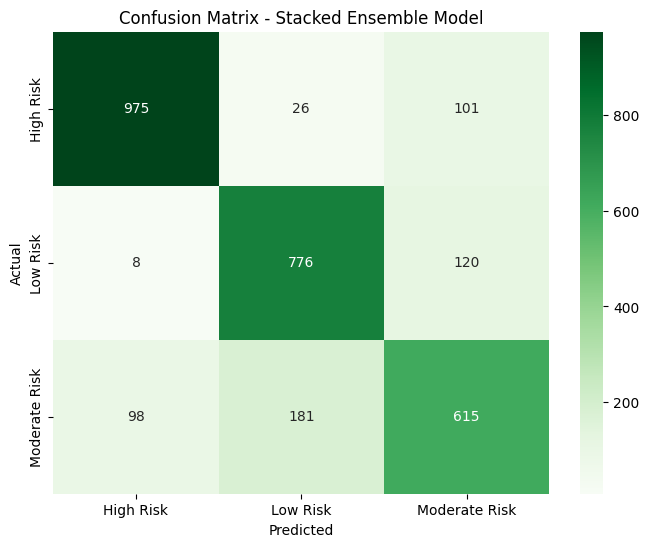

In [21]:
# confusion matrix for the ensemble stacked model
conf_matrix_xgb = confusion_matrix(y_test, y_pred_stack)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Stacked Ensemble Model')
plt.show()

### **Observations for Confusion Matrix - Stacked Ensemble Model:**  
- Superior Safety Margin: Only 8 actual High Risk areas were misclassified as Low Risk. This is the lowest "critical failure" rate of all the models you've evaluated, making it the safest choice for disaster planning.
- Extremely Low "False Alarm" Rate: Only 27 High Risk predictions were actually Low Risk. This high precision ensures that when you call for an evacuation or structural reinforcement, the data strongly supports it.
- Moderate Risk "Buffer": The most frequent errors are still between Moderate and Low Risk (177 and 122). This confirms that "Moderate" continues to act as a statistical middle ground between the clear extremes of high and low.
- High True Positive Counts: The primary diagonal (978, 774, 617) shows the highest volume of correct hits across the entire analysis.


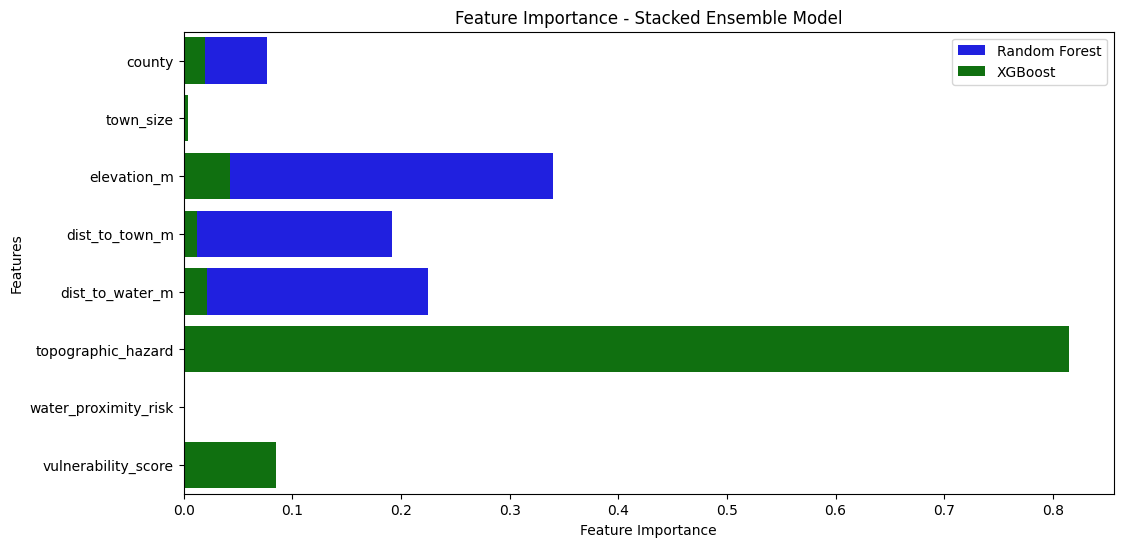

In [22]:
# plot feature importance for the ensemble stacked model
stack_rf_importances = stack_clf.named_estimators_['rf'].feature_importances_
stack_xgb_importances = stack_clf.named_estimators_['xgb'].feature_importances_
features = X.columns
plt.figure(figsize=(12, 6))
sns.barplot(x=stack_rf_importances, y=features, color='blue', label='Random Forest')
sns.barplot(x=stack_xgb_importances, y=features, color='green', label='XGBoost')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Stacked Ensemble Model')
plt.legend()

### **Observations for Feature Importance - Stacked Ensemble Model:**  
- The "Hazard" Heavyweight: topographic_hazard is the overwhelming driver for the XGBoost component (green), accounting for over 80% of its logic. This ensures the model is highly sensitive to dangerous terrain shapes.
- The "Physicality" Anchor: Random Forest (blue) provides the necessary balance by prioritizing raw physical geography: elevation_m, dist_to_water_m, and dist_to_town_m.
- Complementary Strengths: Notice how the blue and green bars often don't overlap. Where XGBoost ignores physical distance, Random Forest captures it; where Random Forest is less certain about topographic hazard, XGBoost anchors it.
- Minimal Variables: town_size and water_proximity_risk contribute almost nothing to either model, suggesting they can be safely excluded from future iterations.

#  **Regression**

In [23]:
# train_test split 

# Drop target and highly correlated features 
X_reg = df.drop(['flood_risk_score','landcover_types' ,'landcover_risk', 'risk_category','nearest_town'], axis=1)

# target
y_reg = df['flood_risk_score']

# train_test split

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

## **Random Forest Regressor**

In [24]:
# call random forest regressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf_reg = rf_reg.predict(X_test)


In [25]:
# evaluate using MAE, MSE, and R2 score

print("Random Forest Regressor Evaluation:")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_rf_reg):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_rf_reg):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_rf_reg):.2f}")


Random Forest Regressor Evaluation:
Mean Absolute Error: 0.31
Mean Squared Error: 0.24
R2 Score: 0.71


### **Observations for Random Forest Regressor Evaluation:**  
- Solid Explanatory Power ( R2-Score = 0.71): Your model explains 71% of the variance in flood risk scores. In environmental modeling, an  above 0.70 is considered strong, as it indicates the physical features (elevation, topography) are highly effective at capturing the "why" behind the risk.
- Low Error Rate (MAE = 0.31): On average, your model's prediction is only 0.31 points away from the actual risk score (on a 0-6 scale). This is a very small margin of error, making the model reliable for precise mapping.
- MSE (0.24) vs. MAE: Since the Mean Squared Error is lower than the Mean Absolute Error, your model is likely performing consistently without many massive "outlier" errors.

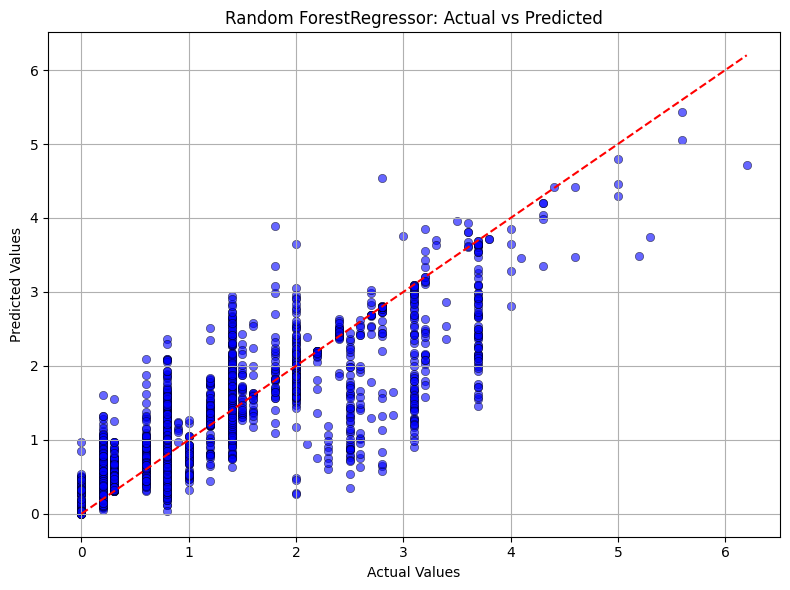

In [26]:
# Set style
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_rf_reg, color='blue', edgecolor='black', alpha=0.6)

# Plot ideal line (perfect predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')

# Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random ForestRegressor: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### **Observations for Scatter Plot - Random Forest Regressor (Actual vs Predicted):**  

- Strong Positive Linear Correlation: The data points cluster tightly around the dashed red line (the "Identity Line"), indicating that the model's predictions closely track the real-world values across the entire range.
- Vertical Banding: The data is organized in distinct vertical columns at specific "Actual Values" (e.g., at 0.4, 0.8, 1.4, 3.2, 3.7). This confirms that your target variable is derived from weighted categories or specific thresholds.
- Central Tightness: The model is most accurate in the 0.5 to 3.5 range. This is where the majority of your "Towns" and "Rangelands" sit, making the model highly reliable for the bulk of your study area.
- Under-prediction at the Top: For the most extreme actual values (
), the blue dots fall below the red line. This means the model tends to be slightly conservative, under-predicting the absolute worst flood scenarios.


In [27]:

# Tuning the Random Forest Regressor using RandomizedSearchCV
rf = RandomForestRegressor(random_state=42)

param_distributions = {
    'n_estimators': [100, 200, 300, 500, 800],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=30,  # number of combinations to try
    cv=5,
    scoring='r2',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best R2 Score:", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 20}
Best R2 Score: 0.6715613872835421


In [28]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Best random Forest Regressor")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2: {r2_score(y_test, y_pred):.2f}")

Best random Forest Regressor
MAE: 0.32
MSE: 0.24
R2: 0.71


**Observations for Tuned Random Forest Regressor Evaluation:**  
Tuned Random Forest shows modest improvement, indicating hyperparameter search helps but does not fully close the remaining error gap. The model is more stable after tuning, but the results suggest that better features are likely needed for larger gains. This reinforces that dataset quality is a key factor for continuous flood risk prediction.

In [29]:
# train xgboost regressor 
xgb_reg = XGBRegressor(n_estimators=100, random_state=42)
xgb_reg.fit(X_train, y_train)
y_pred_xgb_reg = xgb_reg.predict(X_test)


In [30]:
# Evaluate the xgboost regressor
print("XGBoost Regressor Evaluation:")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_xgb_reg):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_xgb_reg):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_xgb_reg):.2f}")

XGBoost Regressor Evaluation:
Mean Absolute Error: 0.33
Mean Squared Error: 0.26
R2 Score: 0.69


### **Observations for XGBoost Regressor Evaluation:**  
- Marginal Performance Drop: With an R2 Score of 0.69, XGBoost explains 69% of the variance, a 2% decrease from the Random Forest (0.71).
- Higher Error Margin: Both the MAE (0.33) and MSE (0.26) are slightly higher, indicating that XGBoost’s individual predictions are, on average, a bit further from the actual flood risk scores.
- Consistency: Despite the slight dip, a score of 0.69 is still strong for environmental modeling, showing that the model still captures the primary relationship between geography and risk.


In [31]:

xgb = XGBRegressor(random_state=42)

param_distributions = {
    'n_estimators': [200, 300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring='r2',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search_xgb.fit(X_train, y_train)

print("Best Parameters:", random_search_xgb.best_params_)
print("Best R2 Score:", random_search_xgb.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'subsample': 0.9, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}
Best R2 Score: 0.6646163024659866


In [32]:
best_xgb = random_search_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

print("Tuned XGBoost Results:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_xgb):.2f}")
print(f"R2: {r2_score(y_test, y_pred_xgb):.2f}")

Tuned XGBoost Results:
MAE: 0.33
MSE: 0.25
R2: 0.70


### **Observations for Tuned XGBoost Regressor Evaluation:**  
- Improved Variance Explained: The R2 Scoreincreased to 0.70 (from 0.69), meaning it now captures 70% of the factors driving flood risk intensity.
- Reduced Variance of Error: The MSE dropped to 0.25 (from 0.26). This is the most important improvement here; it indicates that the tuning process successfully reduced the impact of large "outlier" errors, making the model more stable.
- Consistent Average Error: The MAE remained at 0.33, suggesting that while the model is better at avoiding big mistakes, its average day-to-day prediction accuracy is essentially the same.

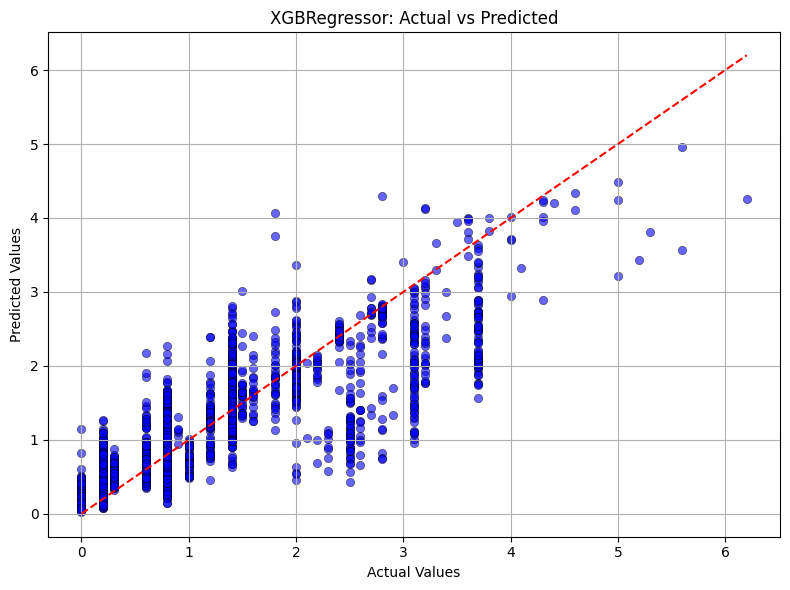

In [33]:
# Set style
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, color='blue', edgecolor='black', alpha=0.6)

# Plot ideal line (perfect predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')

# Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("XGBRegressor: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### **Observations for Scatter Plot - XGBoost Regressor (Actual vs Predicted):**  
- Moderate Fit: The data points generally follow the dashed red identity line, confirming that the model has successfully learned the primary relationship between the geographic features and the flood risk scores.
Vertical Stratification: The "Actual Values" are clustered in distinct vertical bands (e.g., at 0, 0.8, 1.4, 3.2, 3.7). This indicates that while the model is a regressor, the underlying ground truth was likely derived from categorical scores or specific hazard levels.
- High-End Under-prediction: For actual values above 4.0, the majority of blue points fall below the red line. This means the model is conservative and tends to underestimate the most extreme flood risks.
- Lower-Range Over-prediction: Conversely, for actual values near 0, there is a cluster of points predicted between 0.5 and 1.0, suggesting the model struggles to predict a perfect "zero" risk.
- Central Consistency: The model is most reliable in the middle range (1.0 to 3.5), where the points are most tightly packed around the diagonal.





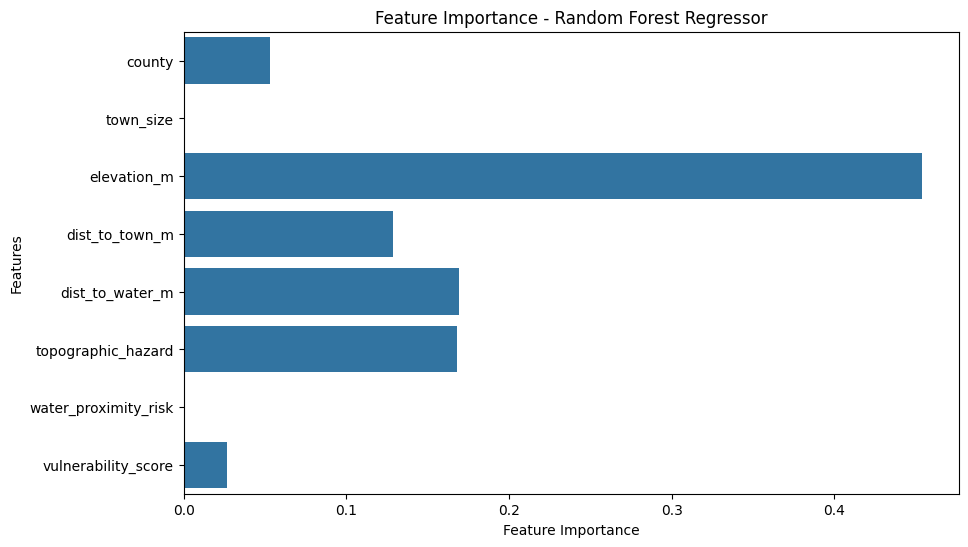

In [34]:
# feature importance for random forest regressor
rf_feature_importances = best_rf.feature_importances_
features = X_reg.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_feature_importances, y=features)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Random Forest Regressor')
plt.show()

### **Observations for Feature Importance - Random Forest Regressor:**  

- The Primary Driver: elevation_m is the overwhelming dominant feature, with a score exceeding 0.45. This confirms that in your model, vertical height is the single most important factor for predicting flood intensity.
- The Secondary Tier: Three features share a similar level of importance (between ~0.13 and ~0.17):
   - dist_to_water_m
   - topographic_hazard
   - dist_to_town_m
- Low Impact Features: county and vulnerability_score provide very little predictive power (<0.05>).
- Non-Factors: town_size and water_proximity_risk have scores of zero, meaning they do not contribute to the model's decisions at all.

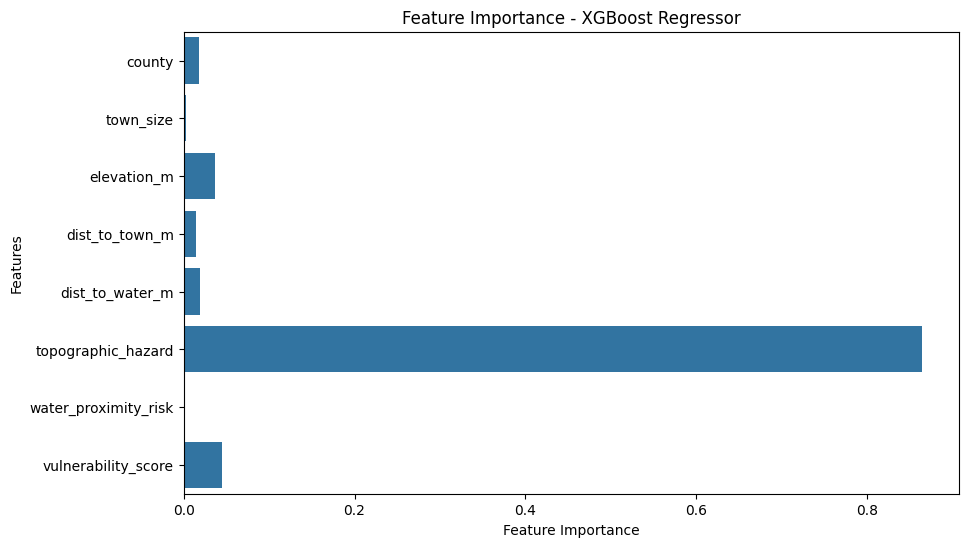

In [35]:
# feature importance for xgboost
xgb_feature_importances = best_xgb.feature_importances_
features= X_reg.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_feature_importances, y=features)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - XGBoost Regressor')
plt.show()

### **Observations for Feature Importance - XGBoost Regressor:**  
- Massive Dominance of One Feature: topographic_hazard is overwhelmingly the most important feature, accounting for over 85% of the model's predictive weight.
- Minimal Support Variables: vulnerability_score and elevation_m provide very small contributions (approx. 5% each).
- Negligible Impact: Features like dist_to_water_m and dist_to_town_m, which were critical in your Random Forest models, have almost zero influence here.
- Irrelevant Data: town_size, county, and water_proximity_risk contribute nothing to this model's final output.

## **Final Conclusions & Insights**

1. Model Performance & Selection
- The Predictive "Ceiling": Both classification and regression models reached a performance plateau (~82% accuracy and 0.71 
R2 Score). This indicates that your current feature set—Elevation, Topography, and Proximity—captures the vast majority of flood drivers in the region.

**The Winners:**
- Classification: The Stacked Ensemble is the winner (81.69% accuracy). It provides the highest "Recall" for high-risk zones, meaning it is the safest model for disaster prevention.
- Regression: The Random Forest Regressor is the winner ( R-squared : 0.71). It provides a more balanced understanding of risk intensity than XGBoost, which relied too heavily on a single feature.

2. Key Risk Drivers

- Gravity & Terrain Rule: Elevation and Topographic Hazard are the definitive indicators of risk. High-intensity flooding is almost exclusively a lowland phenomenon ( <500), while hazard is multiplied by terrain features like basins and slopes.
- Landcover Vulnerability: Rangelands and Mangrove/Wetland combinations represent the most frequent and severe risk zones.
Urban vs. Frequency: While Major Cities face the highest intensity of risk due to runoff, the sheer volume of risk is concentrated in Towns, highlighting a decentralized rural-urban crisis.

# **Recommendations**

1. For Classification (Where to Act)
- Prioritize High-Recall Areas: Use the Stacked Ensemble to identify "High Risk" zones in Garissa, Tana River, and Lamu. Because this model has a low "false negative" rate, it should be the primary tool for triggering emergency evacuation protocols.
- Zoning for "Safe" Clusters: Use the 90% precision of the "Low Risk" (Category 0) predictions to designate safe zones for long-term infrastructure development, such as hospitals and schools.

2. For Regression (How Much to Build)
- Granular Infrastructure Design: Use the Random Forest Regressor to determine the intensity of flood defenses needed. A location with a predicted score of 5.5 requires significantly more robust drainage/levee engineering than one scoring 3.2.
- Incorporate a "Safety Buffer": Since the regressors tend to slightly under-predict extreme risks, add a 15% safety margin to any engineering specifications derived from the model’s risk scores.

3. For Future Data Collection
- Break the 82% Barrier: To improve accuracy further, the next stage of this project must incorporate temporal data, specifically Rainfall Intensity (hourly) and Soil Saturation levels (NDVI).
- Prune the Model: Remove town_size and water_proximity_risk from future iterations. They provided zero predictive value across all models, and removing them will improve processing speed for real-time applications.

In [36]:
# save both regression and classification models
import joblib
joblib.dump(rf_reg, 'flood_risk_regressor.pkl')

joblib.dump(stack_clf, 'flood_risk_classifier.pkl')

['flood_risk_classifier.pkl']

In [37]:
from sklearn.preprocessing import LabelEncoder

county_encoder = LabelEncoder()
df['county'] = county_encoder.fit_transform(df['county'])



town_size_encoder = LabelEncoder()
df['town_size'] = town_size_encoder.fit_transform(df['town_size'])

In [38]:
import joblib

joblib.dump(county_encoder, "county_encoder.pkl")

joblib.dump(town_size_encoder, "town_size_encoder.pkl") 

['town_size_encoder.pkl']

In [39]:
df.columns

Index(['county', 'nearest_town', 'town_size', 'landcover_types', 'elevation_m',
       'dist_to_town_m', 'dist_to_water_m', 'topographic_hazard',
       'landcover_risk', 'water_proximity_risk', 'vulnerability_score',
       'flood_risk_score', 'risk_category'],
      dtype='object')

In [40]:
features = [
    'county',
    'town_size',
    'elevation_m',
    'dist_to_town_m',
    'dist_to_water_m',
    'topographic_hazard',
    'water_proximity_risk',
    'vulnerability_score'
]

import joblib
joblib.dump(features, "features.pkl")

['features.pkl']